# SQLglot SQL parsing

Explore **sqlglot** parsing on the **first SQL statement** from `data/DDLs_10.txt`:

1. Parse SQL into an AST (`parse_one`)
2. Walk nodes, `simplify()`, chunk split
3. Dialects and parse-error handling
4. **`Classes.pipeline`** — unified parse → AST JSON → column lineage (ADDITIONALS.md)
5. Save parse snapshot
6. **Column-oriented lineage** (`SQL2GraphPipeline` + drawer)
7. (Optional) Chunk-level LLM graph agent + drawer

Sections 1–8 are deterministic. LLM steps (pipeline analysis, SQL2Graph, agent) require `HF_TOKEN` (or use `llm_provider=mock` for a dry run).

In [1]:
import json
import os
import sys
from pathlib import Path
from typing import Any, Iterable, List, Optional

ROOT = Path.cwd().resolve()
if ROOT.name == "Notebooks":
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from dotenv import load_dotenv

load_dotenv(ROOT / ".env")

import sqlglot
from sqlglot import exp

from Classes.sql2graph_classes import SQL2GraphParser
from Classes.sql_chunk_classes import SQLLogicalChunkParser
from Classes.pipeline import (
    SQLParser,
    ASTSerializer,
    ColumnLineageExtractor,
    PipelineOrchestrator,
    Config,
    setup_logging,
)

HF_TOKEN = os.environ.get("HF_TOKEN")
MODEL_NAME = os.environ.get("MODEL_NAME", "Qwen/Qwen3-Coder-30B-A3B-Instruct")
PROVIDER = os.environ.get("PROVIDER", "scaleway")
print(f"sqlglot {sqlglot.__version__}")
print(f"ROOT: {ROOT}")
print(f"HF_TOKEN: {'set (...' + HF_TOKEN[-6:] + ')' if HF_TOKEN else 'not set — LLM agent will fail'}")


/Users/nikolajabramov/PycharmProjects/llm4lineage/.venv/lib/python3.14/site-packages/langchain_core/_api/deprecation.py:27: UserWarning: Core Pydantic V1 functionality isn't compatible with Python 3.14 or greater.
  from pydantic.v1.fields import FieldInfo as FieldInfoV1


sqlglot 30.10.0
ROOT: /Users/nikolajabramov/PycharmProjects/llm4lineage
HF_TOKEN: set (...OrZWkc)


## Load SQL

First statement from `data/DDLs_10.txt` (split on `;`).

In [2]:
sql_path = ROOT / "data" / "DDLs_10.txt"
raw_sql_file = sql_path.read_text(encoding="utf-8")
statements = [s.strip() for s in raw_sql_file.split(";") if s.strip()]
SQL = statements[0]

print(f"Source: {sql_path}")
print(f"Statements in file: {len(statements)}")
print(f"First SQL length: {len(SQL)} chars")
print(f"Preview:\n{SQL[:500]}...")

Source: /Users/nikolajabramov/PycharmProjects/llm4lineage/data/DDLs_10.txt
Statements in file: 10
First SQL length: 3447 chars
Preview:
INSERT INTO s_grnplm_vd_t_bvd_db_dmslcl.d_agr_collat_dmcl_attr  WITH pprb_attr_val AS (
         SELECT a_agr_collat_mkt_period.host_eks_id AS host_agr_collat_id,
            a_agr_collat_mkt_period.start_dt,
            a_agr_collat_mkt_period.end_dt,
            'mkt_price_amt'::text AS attr_name,
            a_agr_collat_mkt_period.mkt_price_amt AS attr_val_numeric,
            NULL::uuid AS attr_val_uuid,
            NULL::bigint AS attr_val_bigint
           FROM s_grnplm_vd_t_bvd_db_dmcl.a...


## 1. Basic parse (`parse_one`)

`read=` sets the **input dialect**; `sql(dialect=)` sets the **output dialect** when regenerating SQL.

In [3]:
DIALECT = None  # generic / auto

tree = sqlglot.parse_one(SQL, read=DIALECT)
print("Root node:", type(tree).__name__)
print("Statement type:", tree.key.upper() if hasattr(tree, "key") else type(tree))
print()
print("Regenerated SQL (first 400 chars):")
print(tree.sql(dialect=DIALECT)[:400])

Root node: Insert
Statement type: INSERT

Regenerated SQL (first 400 chars):
INSERT INTO s_grnplm_vd_t_bvd_db_dmslcl.d_agr_collat_dmcl_attr WITH pprb_attr_val AS (SELECT a_agr_collat_mkt_period.host_eks_id AS host_agr_collat_id, a_agr_collat_mkt_period.start_dt, a_agr_collat_mkt_period.end_dt, CAST('mkt_price_amt' AS TEXT) AS attr_name, a_agr_collat_mkt_period.mkt_price_amt AS attr_val_numeric, CAST(NULL AS UUID) AS attr_val_uuid, CAST(NULL AS BIGINT) AS attr_val_bigint FR


## 2. Walk the AST

Use `find()` for the first match and `find_all()` to collect every node of a type.

In [4]:
def summarize_ast(tree: exp.Expression, dialect: Optional[str] = None) -> dict:
    tables = []
    for node in tree.find_all(exp.Table):
        tables.append(
            {
                "table": node.sql(dialect=dialect),
                "alias": node.alias_or_name,
            }
        )

    columns = []
    for node in tree.find_all(exp.Column):
        columns.append(f"{node.table or ''}.{node.name}".strip("."))

    joins = []
    for node in tree.find_all(exp.Join):
        on = node.args.get("on")
        joins.append(
            {
                "kind": (node.args.get("kind") or "inner").upper(),
                "right": node.this.sql(dialect=dialect),
                "on": on.sql(dialect=dialect) if on is not None else "",
            }
        )

    unions = list(tree.find_all(exp.Union))
    ctes = [cte.alias_or_name for cte in tree.find_all(exp.CTE)]

    return {
        "tables": tables,
        "column_refs": sorted(set(columns))[:30],
        "joins": joins,
        "union_nodes": len(unions),
        "cte_names": ctes,
    }


summary = summarize_ast(tree, DIALECT)
print(json.dumps(summary, indent=2))

{
  "tables": [
    {
      "table": "s_grnplm_vd_t_bvd_db_dmslcl.d_agr_collat_dmcl_attr",
      "alias": "d_agr_collat_dmcl_attr"
    },
    {
      "table": "pprb_attr_val AS t1 JOIN s_grnplm_vd_t_bvd_db_dmslcl.d_agr_collat AS t2 ON ((t1.host_agr_collat_id = t2.host_agr_collat_id))",
      "alias": "t1"
    },
    {
      "table": "s_grnplm_vd_t_bvd_db_dmslcl.d_agr_collat AS t2",
      "alias": "t2"
    },
    {
      "table": "s_grnplm_vd_t_bvd_db_dmcl.a_agr_collat_qlty_period AS a JOIN s_grnplm_vd_t_bvd_db_dmcl.d_agr_collat AS t ON ((a.agr_collat_id = t.agr_collat_id))",
      "alias": "a"
    },
    {
      "table": "s_grnplm_vd_t_bvd_db_dmcl.a_agr_collat_qlty_period AS a JOIN s_grnplm_vd_t_bvd_db_dmcl.d_agr_collat AS t ON ((a.agr_collat_id = t.agr_collat_id))",
      "alias": "a"
    },
    {
      "table": "s_grnplm_vd_t_bvd_db_dmcl.a_agr_collat_mkt_period",
      "alias": "a_agr_collat_mkt_period"
    },
    {
      "table": "s_grnplm_vd_t_bvd_db_dmcl.a_agr_collat_mkt_period",


## 3. Node type histogram

Quick view of which AST node kinds appear in a large statement.

In [5]:
from collections import Counter

counts = Counter(type(node).__name__ for node in tree.walk() if hasattr(node, "walk"))
for name, count in counts.most_common(15):
    print(f"{name:20} {count}")

Identifier           155
Column               47
Alias                26
Paren                20
Cast                 16
DataType             16
Null                 15
Table                13
TableAlias           10
EQ                   7
Select               6
From                 6
Subquery             6
Join                 6
Literal              6


## 4. `SQL2GraphParser.simplify()`

Project wrapper: tables, joins, filters, CTEs, and subgraph blocks for lineage.

In [6]:
parser = SQL2GraphParser()

simplified = parser.simplify(SQL, dialect=DIALECT)
print("parser_used:", simplified.get("parser_used"))
print("statement_type:", simplified.get("statement_type"))
print("target_table:", simplified.get("target_table"))
print("from:", simplified.get("from"))
print("joins:", simplified.get("joins"))
print("ctes:", [c["alias"] for c in simplified.get("ctes") or []])
print("deterministic_filters:", simplified.get("deterministic_filters"))
print("subgraph_blocks:", [b["type"] + ":" + b["name"] for b in simplified.get("subgraph_blocks") or []])
print("select aliases (first 8):", (simplified.get("select") or {}).get("aliases", [])[:8])
print("column_lineage count:", len(simplified.get("column_lineage") or []))
print("ast_summary root type:", (simplified.get("ast_summary") or {}).get("type"))
if simplified.get("column_lineage"):
    print("first lineage entry:", json.dumps(simplified["column_lineage"][0], indent=2))

parser_used: True
statement_type: insert
target_table: d_agr_collat_dmcl_attr
from: [{'table': 'pprb_attr_val', 'alias': 't1'}, {'table': 'd_agr_collat', 'alias': 't2'}]
joins: []
ctes: ['pprb_attr_val']
deterministic_filters: []
subgraph_blocks: ['cte:pprb_attr_val', 'union_block:union_0_left', 'union_block:union_0_right', 'union_block:union_1_left', 'union_block:union_1_right', 'union_block:union_2_left', 'union_block:union_2_right', 'union_block:union_3_left', 'union_block:union_3_right']
select aliases (first 8): ['agr_collat_id', 'host_agr_collat_id', 'start_dt', 'end_dt', 'attr_name', 'attr_val_numeric', 'attr_val_uuid', 'attr_val_uuid2bigint']


In [7]:
# Compact view of simplify() for DDLs_10 first statement
print(json.dumps(
    {
        "statement_type": simplified.get("statement_type"),
        "target_table": simplified.get("target_table"),
        "cte_count": len(simplified.get("ctes") or []),
        "join_count": len(simplified.get("joins") or []),
        "subgraph_block_types": dict(Counter(b["type"] for b in simplified.get("subgraph_blocks") or [])),
        "deterministic_filter_count": len(simplified.get("deterministic_filters") or []),
    },
    indent=2,
))

{
  "statement_type": "insert",
  "target_table": "d_agr_collat_dmcl_attr",
  "cte_count": 1,
  "join_count": 0,
  "subgraph_block_types": {
    "cte": 1,
    "union_block": 8
  },
  "deterministic_filter_count": 0
}


## 4b. Unified pipeline (`Classes.pipeline`)

Deterministic stack from **ADDITIONALS.md** — shared by `SQL2GraphParser`, chunk parser, and `PipelineOrchestrator`:

`SQLParser` → `ASTSerializer` → `ColumnLineageExtractor` → (optional) LLM analysis

In [ ]:
PIPELINE_DIALECT = DIALECT or "postgres"  # DDLs_10 uses PostgreSQL-style :: casts

sql_parser = SQLParser(dialect=PIPELINE_DIALECT, error_on_incomplete=True)
ast_serializer = ASTSerializer(max_depth=50)
lineage_extractor = ColumnLineageExtractor(dialect=PIPELINE_DIALECT)

pipeline_tree = sql_parser.parse(SQL)
pipeline_ast = ast_serializer.serialize(pipeline_tree)
pipeline_lineage = lineage_extractor.extract(pipeline_tree)

print(f"AST root: {pipeline_ast['type']}")
print(f"AST children: {len(pipeline_ast.get('children', []))}")
print(f"Output columns (lineage): {len(pipeline_lineage)}")
print("\nFirst 3 lineage records:")
for entry in pipeline_lineage[:3]:
    print(f"  {entry['target_column']:25} <- {[c['column'] for c in entry['source_columns']]}")

# Cross-check: simplify() embeds the same pipeline output
assert len(simplified.get("column_lineage") or []) == len(pipeline_lineage)
assert (simplified.get("ast_summary") or {}).get("type") == pipeline_ast["type"]
print("\n✓ simplify() column_lineage / ast_summary match pipeline components")

### Pipeline orchestrator (parse + lineage + LLM)

Run the full `PipelineOrchestrator`. Uses `mock` when `HF_TOKEN` is unset; otherwise your configured HF inference router.

In [ ]:
setup_logging("INFO")

llm_provider = "huggingface_inference" if HF_TOKEN else "mock"
pipeline_config = Config(
    llm_provider=llm_provider,
    sql_dialect=PIPELINE_DIALECT,
    model_name=MODEL_NAME,
    inference_provider=PROVIDER,
    hf_api_token=HF_TOKEN or "",
    hf_max_new_tokens=1024,
    llm_temperature=0.1,
)

orchestrator = PipelineOrchestrator(pipeline_config)
pipeline_result = orchestrator.run(
    SQL,
    instruction="Summarise the INSERT target, CTEs, and how output columns map to source tables.",
)

print(f"success: {pipeline_result.success}")
print(f"model: {pipeline_result.model_used}")
print(f"latency: {pipeline_result.latency_seconds}s")
print(f"lineage columns: {len(pipeline_result.column_lineage)}")
if pipeline_result.error:
    print(f"error: {pipeline_result.error}")
else:
    print("\nLLM response (first 800 chars):")
    print(pipeline_result.llm_response[:800])

## 5. Deterministic chunk split (`SQLLogicalChunkParser`)

Step 1 of the chunk pipeline — no LLM.

In [8]:
chunk_parser = SQLLogicalChunkParser(hf_token=None)

chunk_result = chunk_parser.preparse(SQL, dialect=DIALECT)
print("Chunks:")
for ch in chunk_result.get("chunks") or []:
    preview = (ch.get("sql") or "")[:80].replace("\n", " ")
    print(f"  - {ch['id']} ({ch.get('chunk_type')}): {preview}...")

print("\nLinks:")
for link in chunk_result.get("links") or []:
    cond = (link.get("condition") or "")[:60]
    print(f"  {link['source']} --[{link.get('link_type')}]--> {link['target']}  {cond}")

Chunks:
  - pprb_attr_val (cte): SELECT a_agr_collat_mkt_period.host_eks_id AS host_agr_collat_id, a_agr_collat_m...
  - d_agr_collat_dmcl_attr (target): d_agr_collat_dmcl_attr...
  - main (query): SELECT t2.agr_collat_id, t1.host_agr_collat_id, t1.start_dt, t1.end_dt, t1.attr_...

Links:
  main --[INSERT]--> d_agr_collat_dmcl_attr  


In [9]:
print("Chunk ids:", [c["id"] for c in chunk_result.get("chunks") or []])
print("Link count:", len(chunk_result.get("links") or []))

Chunk ids: ['pprb_attr_val', 'd_agr_collat_dmcl_attr', 'main']
Link count: 1


## 6. Dialect comparison

Parse the **same** `DDLs_10` statement with different `read=` dialects (PostgreSQL-style `::type` casts are common in this SQL).

In [10]:
for dialect in [None, "postgres", "hive", "spark"]:
    label = dialect or "default"
    try:
        parsed = sqlglot.parse_one(SQL, read=dialect)
        print(f"{label:10} OK  root={type(parsed).__name__}  nodes={sum(1 for _ in parsed.walk())}")
    except Exception as exc:
        print(f"{label:10} FAIL -> {exc}")

default    OK  root=Insert  nodes=381
postgres   OK  root=Insert  nodes=381
hive       OK  root=Insert  nodes=381
spark      OK  root=Insert  nodes=381


## 7. Parse errors

Confirm the `DDLs_10` statement parses, then contrast with intentionally invalid SQL.

In [11]:
from sqlglot.errors import ParseError

try:
    sqlglot.parse_one(SQL, read=DIALECT)
    print("DDLs_10 first statement: parse OK")
except ParseError as exc:
    print("DDLs_10 first statement: ParseError:", exc)

BAD_SQL = "SELECT FROM WHERE"
try:
    sqlglot.parse_one(BAD_SQL)
except ParseError as exc:
    print("Intentionally bad SQL:", exc)

fallback = parser.simplify(BAD_SQL)
print(
    "simplify on bad SQL:",
    {k: fallback.get(k) for k in ("parser_used", "raw_sql", "parse_error")},
)


DDLs_10 first statement: parse OK
Intentionally bad SQL: Expected table name but got <Token token_type: TokenType.WHERE, text: WHERE, line: 1, col: 17, start: 12, end: 16, comments: []>. Line 1, Col: 17.
  SELECT FROM WHERE
simplify on bad SQL: {'parser_used': False, 'raw_sql': 'SELECT FROM WHERE', 'parse_error': 'Expected table name but got <Token token_type: TokenType.WHERE, text: WHERE, line: 1, col: 17, start: 12, end: 16, comments: []>. Line 1, Col: 17.\n  SELECT FROM \x1bWHERE\x1b'}


## 8. Save parse snapshot

Write `simplify()` and chunk-split results for the first `DDLs_10` statement to `data/`.

In [12]:
out_path = ROOT / "data" / "sqlglot_ddls10_first_snapshot.json"
snapshot = {
    "source_file": str(sql_path),
    "sqlglot_version": sqlglot.__version__,
    "sql_length": len(SQL),
    "sql": SQL,
    "simplify": simplified,
    "chunks": chunk_result,
    "column_lineage": simplified.get("column_lineage") or pipeline_lineage,
    "ast_summary": simplified.get("ast_summary") or pipeline_ast,
    "pipeline_llm": {
        "success": pipeline_result.success,
        "model_used": pipeline_result.model_used,
        "latency_seconds": pipeline_result.latency_seconds,
        "llm_response_preview": (pipeline_result.llm_response or "")[:500],
        "error": pipeline_result.error,
    },
}
out_path.write_text(json.dumps(snapshot, indent=2, default=str), encoding="utf-8")
print(f"Saved {out_path}")

Saved /Users/nikolajabramov/PycharmProjects/llm4lineage/data/sqlglot_ddls10_first_snapshot.json


## 9. Column-oriented lineage (SQL2Graph)

LLM extracts **column-level** lineage: `source_column` → `output_column` via `DERIVED_FROM`, plus `FILTERED_BY`, `JOINS_ON`, etc.

Uses sqlglot `simplify()` output as context. Requires `HF_TOKEN` (slow — full SQL may take 1–3 minutes).

In [13]:
import importlib
from Classes import sql2graph_classes as sql2graph_module

sql2graph_module = importlib.reload(sql2graph_module)
SQL2GraphLLMExtractor = sql2graph_module.SQL2GraphLLMExtractor
SQL2GraphPipeline = sql2graph_module.SQL2GraphPipeline

if not HF_TOKEN:
    raise ValueError("Set HF_TOKEN in .env for column lineage extraction.")

MODEL = os.environ.get("MODEL_NAME", "Qwen/Qwen3-Coder-30B-A3B-Instruct")
PROVIDER = os.environ.get("PROVIDER", "scaleway")

column_pipeline = SQL2GraphPipeline(
    llm_extractor=SQL2GraphLLMExtractor(
        model=MODEL,
        provider=PROVIDER,
        hf_token=HF_TOKEN,
        max_new_tokens=4096,
        temperature=0.0,
        max_retries=2,
        enable_refinement=True,
    ),
    parser=parser,
)

column_result = column_pipeline.run(sql=SQL, dialect=DIALECT, include_visualization=False)

if "error" in column_result:
    print("ERROR:", column_result["error"])
    if column_result.get("details"):
        print(column_result["details"])
else:
    graph = column_result["graph"]
    edges = graph.get("links", graph.get("edges", []))
    print("Column lineage OK")
    print("Nodes:", len(graph.get("nodes", [])))
    print("Edges:", len(edges))
    print("DAG:", column_result.get("metadata", {}).get("is_dag"))
    print("Warnings:", len(column_result.get("warnings", [])))
    output_cols = [n["id"] for n in graph.get("nodes", []) if n.get("node_type") == "output_column"]
    print("Output columns (first 10):", output_cols[:10])

    column_path = ROOT / "data" / "sqlglot_ddls10_column_lineage.json"
    column_path.write_text(json.dumps(column_result, indent=2, default=str), encoding="utf-8")
    print(f"Saved {column_path}")

Column lineage OK
Nodes: 29
Edges: 37
DAG: True
Warnings: 0
Output columns (first 10): ['output.agr_collat_id', 'output.host_agr_collat_id', 'output.start_dt', 'output.end_dt', 'output.attr_name', 'output.attr_val_numeric', 'output.attr_val_uuid', 'output.attr_val_uuid2bigint']
Saved /Users/nikolajabramov/PycharmProjects/llm4lineage/data/sqlglot_ddls10_column_lineage.json


## 10. Column lineage drawer

Interactive graph: click an **output column** to highlight full upstream/downstream column lineage.

In [14]:
import importlib
from Classes import graph_drawer as graph_drawer_module

graph_drawer_module = importlib.reload(graph_drawer_module)
JsonLineageDrawer = graph_drawer_module.JsonLineageDrawer

if "error" in column_result:
    raise ValueError("Column lineage failed — fix section 9 before drawing.")

column_drawer = JsonLineageDrawer.from_sql2graph_result(column_result)
column_drawer.print_summary()

LINEAGE JSON SUMMARY
Nodes: 29
Links: 37
Node types: {'output_column': 8, 'source_column': 20, 'filter': 1}
Link types: DERIVED_FROM, FILTERED_BY, JOINS_ON, USES_COLUMN
Sample node ids: ['output.agr_collat_id', 't2.agr_collat_id', 'output.host_agr_collat_id', 't1.host_agr_collat_id', 'output.start_dt', 't1.start_dt', 'output.end_dt', 't1.end_dt', 'output.attr_name', 't1.attr_name', 'output.attr_val_numeric', 't1.attr_val_numeric', 'output.attr_val_uuid', 't1.attr_val_uuid', 'output.attr_val_uuid2bigint', 't1.attr_val_bigint', 't2.host_agr_collat_id', 'pprb_attr_val.host_agr_collat_id', 'a_agr_collat_mkt_period.host_eks_id', 'pprb_attr_val.start_dt']


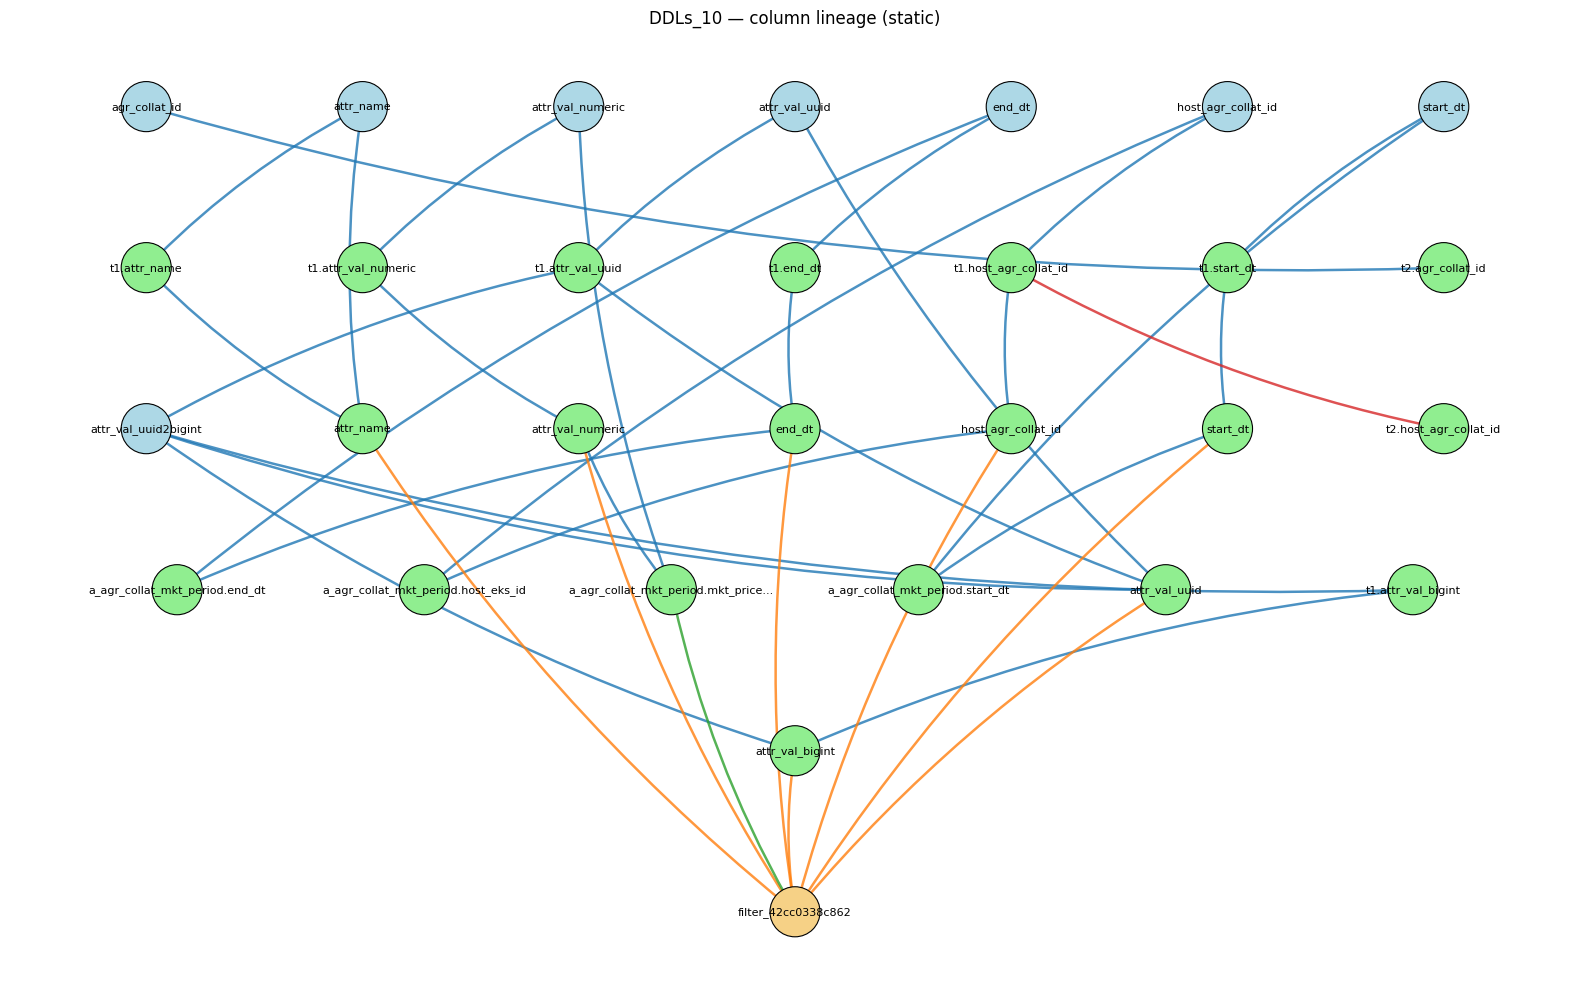

In [15]:
column_drawer.show_static(title="DDLs_10 — column lineage (static)")

In [16]:
column_drawer.show_interactive(
    title="DDLs_10 — column lineage (interactive)",
    height="800px",
)


    'data': [{'hoverinfo': 'skip',
              'legendgroup': 'edges',
       …

## 11. (Optional) Chunk-level LLM graph agent

`LineageGraphAgent` reads sqlglot parse JSON (simplify + chunks + AST summary), calls the LLM to **identify missing links** and correct chunks, and writes drawer-ready graph JSON.

Requires `HF_TOKEN` in `.env`.

In [17]:
import importlib
from Classes import lineage_graph_agent as lineage_graph_agent_module

lineage_graph_agent_module = importlib.reload(lineage_graph_agent_module)
LineageGraphAgent = lineage_graph_agent_module.LineageGraphAgent

if not HF_TOKEN:
    raise ValueError("Set HF_TOKEN in .env before running the LLM graph agent.")

graph_agent = LineageGraphAgent(hf_token=HF_TOKEN)
graph_result = graph_agent.build_graph(
    sql=SQL,
    chunk_result=chunk_result,
    simplify=simplified,
    ast_summary=summarize_ast(tree, DIALECT),
)

print("LLM graph links:")
for link in graph_result.get("links") or []:
    cond = (link.get("condition") or "")[:60]
    print(f"  {link['source']} --[{link.get('link_type')}]--> {link['target']}  {cond}")
print("Warnings:", graph_result.get("warnings"))

graph_path = ROOT / "data" / "sqlglot_ddls10_graph.json"
graph_path.write_text(json.dumps(graph_result, indent=2), encoding="utf-8")
print(f"Saved {graph_path}")

LLM graph links:
  main --[INSERT]--> d_agr_collat_dmcl_attr  
  main --[JOIN]--> pprb_attr_val  t1.host_agr_collat_id = t2.host_agr_collat_id
  pprb_attr_val --[UNION ALL]--> pprb_attr_val  
Warnings: []
Saved /Users/nikolajabramov/PycharmProjects/llm4lineage/data/sqlglot_ddls10_graph.json


## 12. (Optional) Chunk-level drawer

`JsonLineageDrawer` loads the **LLM-enriched chunk graph** JSON (logical SQL chunks, not columns).

In [18]:
import importlib
from Classes import graph_drawer as graph_drawer_module

graph_drawer_module = importlib.reload(graph_drawer_module)
JsonLineageDrawer = graph_drawer_module.JsonLineageDrawer

graph_path = ROOT / "data" / "sqlglot_ddls10_graph.json"
drawer = JsonLineageDrawer.from_path(graph_path)
drawer.print_summary()

LINEAGE JSON SUMMARY
Source: /Users/nikolajabramov/PycharmProjects/llm4lineage/data/sqlglot_ddls10_graph.json
Nodes: 3
Links: 3
Node types: {'chunk': 3}
Chunk types: cte, query, target
Link types: INSERT, JOIN, UNION ALL
Sample node ids: ['pprb_attr_val', 'd_agr_collat_dmcl_attr', 'main']


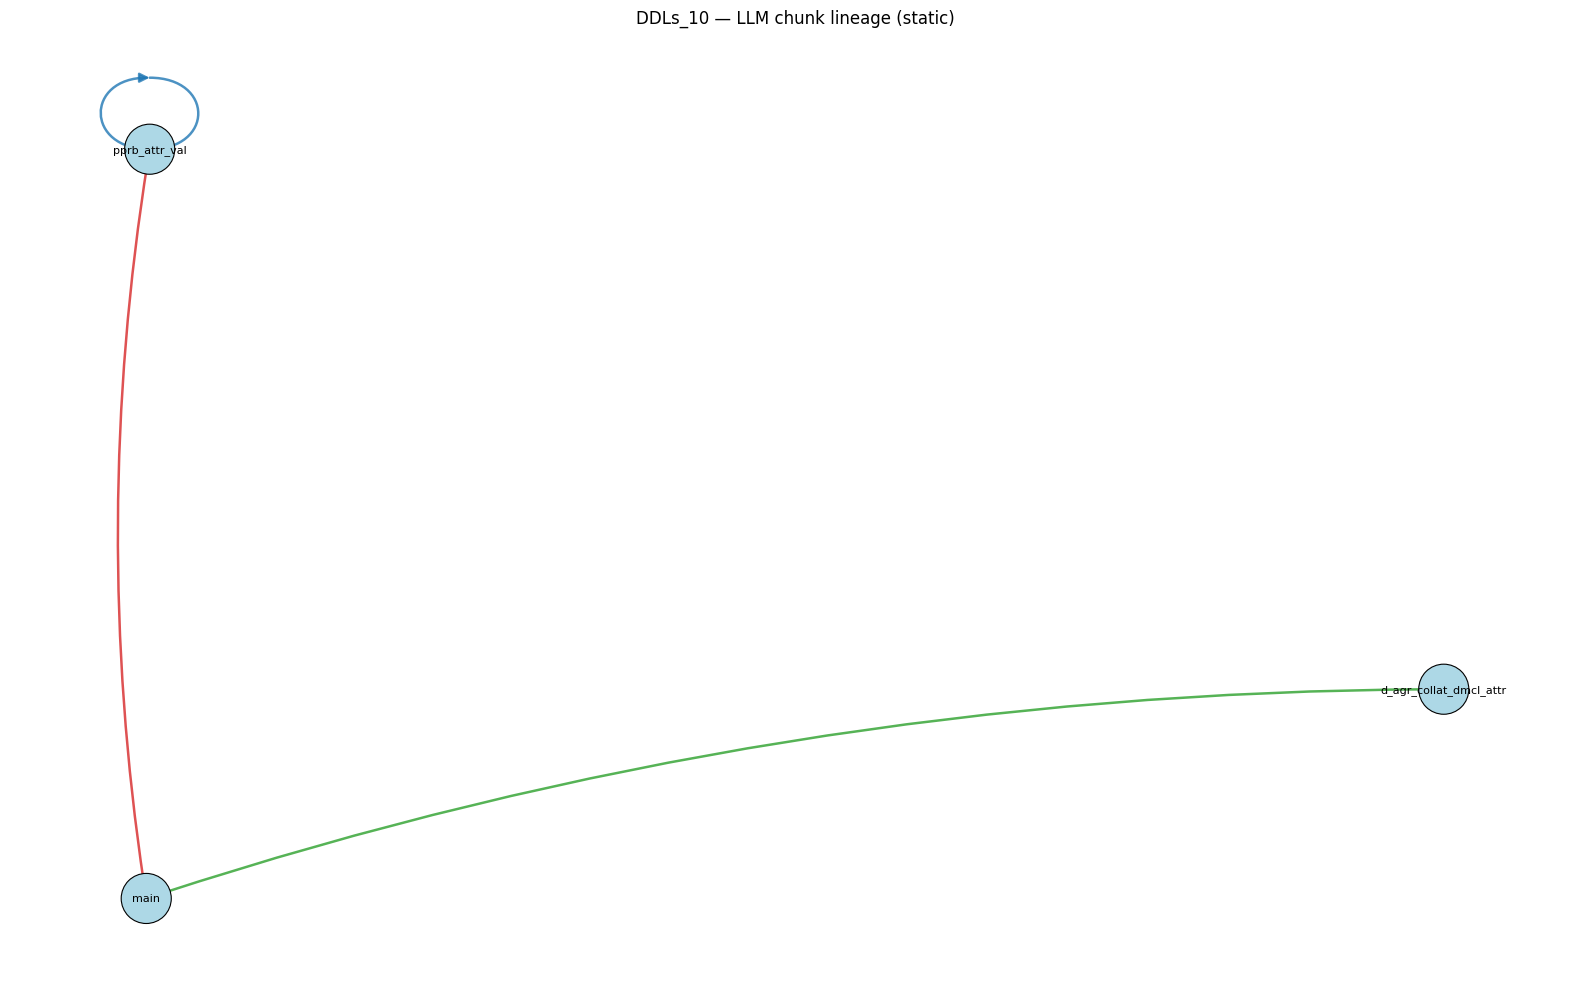

In [19]:
# Static matplotlib graph
drawer.show_static(title="DDLs_10 — LLM chunk lineage (static)")

In [20]:
# Interactive graph (Plotly widget; fallback to HTML if widgets unavailable)
drawer.show_interactive(
    title="DDLs_10 — LLM chunk lineage (interactive)",
    height="640px",
)

    'data': [{'hoverinfo': 'skip',
              'legendgroup': 'edges',
       …

In [21]:
html_path = drawer.save_html(
    ROOT / "data" / "sqlglot_ddls10_lineage.html",
    title="DDLs_10 — chunk lineage",
)
print(f"Standalone HTML: {html_path}")

Standalone HTML: /Users/nikolajabramov/PycharmProjects/llm4lineage/data/sqlglot_ddls10_lineage.html
